Import Libraries


In [1]:
import os
import shutil
import xml.etree.ElementTree as ET
from pathlib import Path
from matplotlib import pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import cv2


Define Path 

In [2]:
TRAIN_IMG = "./NEU-DET/train/images"
VAL_IMG = "./NEU-DET/validation/images"
TRAIN_ANN = "./NEU-DET/train/annotations"
VAL_ANN = "./NEU-DET/validation/annotations"
OUTPUT_TRAIN_IMG = "./Dataset/images/train"
OUTPUT_TRAIN_LBL = "./Dataset/labels/train"
OUTPUT_VAL_IMG = "./Dataset/images/validation"
OUTPUT_VAL_LBL = "./Dataset/labels/validation"

# Class mapping
CLASS_MAP = {"crazing": 0, "inclusion": 1, "patches": 2, "pitted_surface": 3, "rolled-in_scale": 4, "scratches": 5}

Convert from pascal voc to yolo format

In [3]:
def convert_voc_to_yolo(xml_path, img_w, img_h):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    lines = []

    for obj in root.findall("object"):
        cls_name = obj.find("name").text.lower()
        if cls_name not in CLASS_MAP:
            continue

        bndbox = obj.find("bndbox")
        xmin = int(bndbox.find("xmin").text)
        ymin = int(bndbox.find("ymin").text)
        xmax = int(bndbox.find("xmax").text)
        ymax = int(bndbox.find("ymax").text)

        x_center = ((xmin + xmax) / 2) / img_w  # Normalization
        y_center = ((ymin + ymax) / 2) / img_h
        width = (xmax - xmin) / img_w
        height = (ymax - ymin) / img_h

        lines.append(f"{CLASS_MAP[cls_name]} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")

    return lines


def find_image_path(image_dir, stem):
    for extension in (".jpg", ".jpeg"):
        candidate = image_dir / f"{stem}{extension}"
        if candidate.exists():
            return candidate

    matches = list(image_dir.rglob(f"{stem}.*"))
    return matches[0] if matches else None


def convert_split(annotation_dir, image_dir, output_image_dir, output_label_dir):
    if output_image_dir.exists():
        shutil.rmtree(output_image_dir)
    if output_label_dir.exists():
        shutil.rmtree(output_label_dir)

    output_image_dir.mkdir(parents=True, exist_ok=True)
    output_label_dir.mkdir(parents=True, exist_ok=True)

    processed_count = 0
    skipped_files = []

    #parsing xml file
    for xml_path in sorted(annotation_dir.glob("*.xml")):  
        image_path = find_image_path(image_dir, xml_path.stem)
        if image_path is None:
            skipped_files.append(xml_path.name)
            continue

        with Image.open(image_path) as image_file:
            image_width, image_height = image_file.size

        yolo_lines = convert_voc_to_yolo(xml_path, image_width, image_height)
        shutil.copy2(image_path, output_image_dir / image_path.name)
        (output_label_dir / f"{xml_path.stem}.txt").write_text("".join(yolo_lines), encoding="utf-8")
        processed_count += 1

    return processed_count, skipped_files


splits = {
    "train": (Path(TRAIN_ANN), Path(TRAIN_IMG), Path(OUTPUT_TRAIN_IMG), Path(OUTPUT_TRAIN_LBL)),
    "validation": (Path(VAL_ANN), Path(VAL_IMG), Path(OUTPUT_VAL_IMG), Path(OUTPUT_VAL_LBL)),
}

summary = {}
for split_name, (annotation_dir, image_dir, output_image_dir, output_label_dir) in splits.items():
    processed_count, skipped_files = convert_split(annotation_dir, image_dir, output_image_dir, output_label_dir)
    summary[split_name] = {"processed": processed_count, "skipped": skipped_files}
    print(f"{split_name}: converted {processed_count} images")
    if skipped_files:
        print(f"{split_name}: skipped {len(skipped_files)} XML files")


train: converted 1439 images
validation: converted 360 images
validation: skipped 1 XML files


Visualizate before and after conversion sample

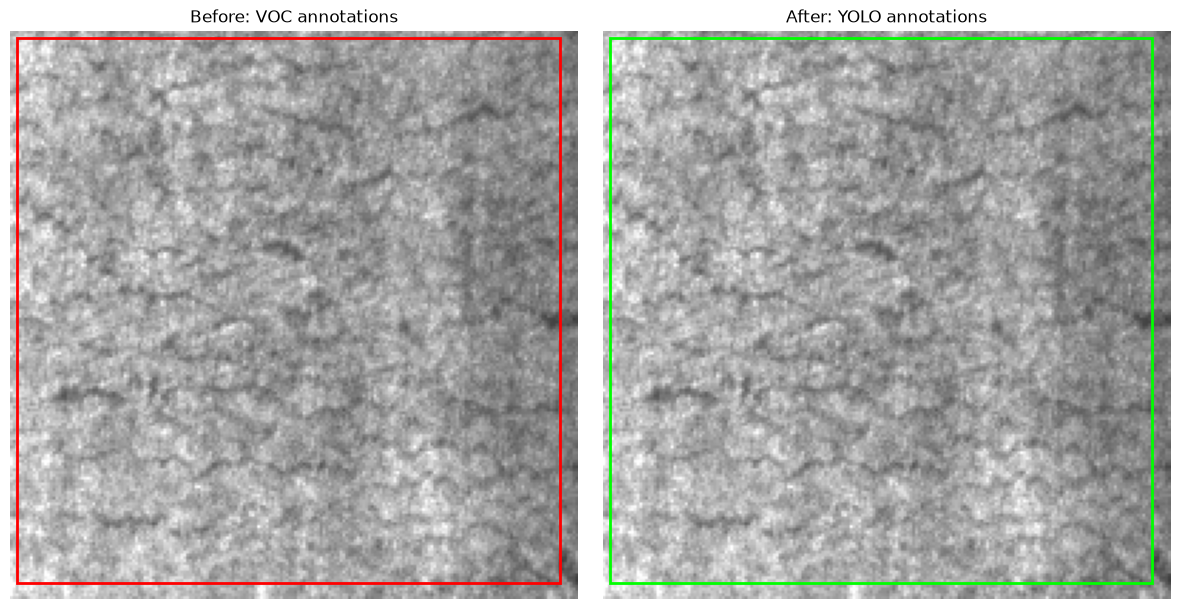

In [4]:
def visualize_voc_vs_yolo(image_path, annotation_path, img_w=None, img_h=None):
    image = cv2.imread(str(image_path))
    if image is None:
        raise FileNotFoundError(f"Image not found: {image_path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    if img_w is None or img_h is None:
        img_h, img_w = image.shape[:2]

    tree = ET.parse(annotation_path)
    root = tree.getroot()

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(image)
    axes[0].set_title("Before: VOC annotations")
    axes[0].axis("off")

    axes[1].imshow(image.copy())
    axes[1].set_title("After: YOLO annotations")
    axes[1].axis("off")

    for obj in root.findall("object"):
        cls_name = obj.find("name").text.lower()
        if cls_name not in CLASS_MAP:
            continue

        bndbox = obj.find("bndbox")
        xmin = int(bndbox.find("xmin").text)
        ymin = int(bndbox.find("ymin").text)
        xmax = int(bndbox.find("xmax").text)
        ymax = int(bndbox.find("ymax").text)

        voc_rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )
        axes[0].add_patch(voc_rect)

        x_center = ((xmin + xmax) / 2) / img_w
        y_center = ((ymin + ymax) / 2) / img_h
        width = (xmax - xmin) / img_w
        height = (ymax - ymin) / img_h

        x_min = int((x_center - width / 2) * img_w)
        y_min = int((y_center - height / 2) * img_h)
        x_max2 = int((x_center + width / 2) * img_w)
        y_max2 = int((y_center + height / 2) * img_h)

        yolo_rect = patches.Rectangle(
            (x_min, y_min),
            x_max2 - x_min,
            y_max2 - y_min,
            linewidth=2,
            edgecolor="lime",
            facecolor="none",
        )
        axes[1].add_patch(yolo_rect)

    plt.tight_layout()
    plt.show()


sample_xml = next(Path(TRAIN_ANN).glob("*.xml"), None)
if sample_xml is None:
    print("No XML annotations found in the training folder.")
else:
    sample_image = find_image_path(Path(TRAIN_IMG), sample_xml.stem)
    if sample_image is None:
        print("No matching image found for the sample annotation.")
    else:
        visualize_voc_vs_yolo(sample_image, sample_xml)
